<a href="https://colab.research.google.com/github/Afreen-1517/CHURN-RATE-ANALYTICS/blob/main/Churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Dataset/Bank_Churn_Classification_Dataset.csv')

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10000 non-null  int64  
 1   CustomerID      10000 non-null  int64  
 2   Gender          10000 non-null  object 
 3   SeniorCitizen   10000 non-null  int64  
 4   Tenure          10000 non-null  int64  
 5   MonthlyCharges  10000 non-null  float64
 6   Contract        10000 non-null  object 
 7   PaymentMethod   10000 non-null  object 
 8   Churn           10000 non-null  int64  
 9   TotalCharges    10000 non-null  float64
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


,Unnamed: 0,CustomerID,SeniorCitizen,Tenure,MonthlyCharges,Churn,TotalCharges
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,4999.50000,0.499300,35.955000,70.451038,0.267000,2541.807390
std,2886.89568,2886.89568,0.500025,20.501761,28.935692,0.442414,1879.645307
min,0.00000,0.00000,0.000000,1.000000,20.000000,0.000000,21.200000
25%,2499.75000,2499.75000,0.000000,18.000000,45.527500,0.000000,1035.057500
50%,4999.50000,4999.50000,0.000000,36.000000,70.585000,0.000000,2117.135000
75%,7499.25000,7499.25000,1.000000,54.000000,95.612500,1.000000,3717.352500
max,9999.00000,9999.00000,1.000000,71.000000,120.000000,1.000000,8384.390000


In [ ]:
df.isnull().sum()

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.dropna(inplace=True)

<Axes: xlabel='Churn', ylabel='count'>

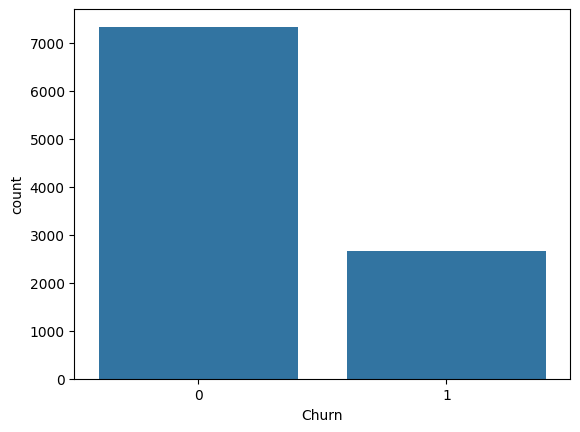

In [ ]:
#Exploratory data analysis
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

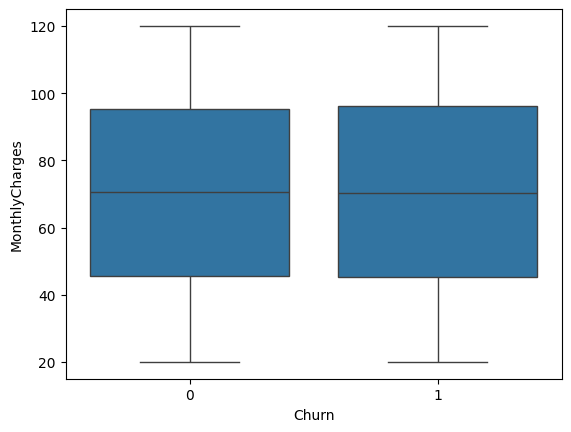

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

In [ ]:
#feature Engineering
df['AvgCharge'] = df['TotalCharges'] / df['Tenure']

In [ ]:
df.to_csv("cleaned_churn.csv", index=False)

In [ ]:
#SQL queries
import sqlite3

conn = sqlite3.connect('churn.db')
df.to_sql('customers', conn, if_exists='replace', index=False)

10000

In [ ]:
#Churn Rate
query = """
SELECT
ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS churn_rate
FROM customers;
"""

pd.read_sql(query, conn)

,churn_rate
0,0.0


In [ ]:
#Customer Contract
query = """
SELECT Contract,
COUNT(*) AS total_customers,
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned
FROM customers
GROUP BY Contract;
"""

pd.read_sql(query, conn)

#Month-to-month customers have the highest churn, indicating lack of long-term commitment.

,Contract,total_customers,churned
0,Month-to-month,3219,0
1,One year,3455,0
2,Two year,3326,0


In [ ]:
#Revenue Loss
query = """
SELECT SUM(MonthlyCharges) AS revenue_loss
FROM customers
WHERE Churn='Yes';
"""

pd.read_sql(query, conn)

,revenue_loss
0,None


In [ ]:
#High risk customers
query = """
SELECT *
FROM customers
WHERE tenure < 12
AND MonthlyCharges > 70
AND Contract = 'Month-to-month';
"""

pd.read_sql(query, conn)

,Unnamed: 0,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges,AvgCharge
0,81,81,Female,1,7,115.18,Month-to-month,Bank transfer,0,806.26,115.18
1,227,227,Female,0,11,76.39,Month-to-month,Electronic check,0,840.29,76.39
2,261,261,Female,1,7,79.81,Month-to-month,Mailed check,0,558.67,79.81
3,280,280,Female,1,2,92.57,Month-to-month,Credit card,1,185.14,92.57
4,496,496,Male,1,10,70.31,Month-to-month,Mailed check,0,703.10,70.31
...,...,...,...,...,...,...,...,...,...,...,...
192,9664,9664,Female,0,2,81.95,Month-to-month,Bank transfer,0,163.90,81.95
193,9832,9832,Female,1,1,79.16,Month-to-month,Bank transfer,1,79.16,79.16
194,9855,9855,Male,0,10,112.70,Month-to-month,Bank transfer,0,1127.00,112.70
195,9942,9942,Female,0,11,87.28,Month-to-month,Mailed check,0,960.08,87.28


In [ ]:
#Customer Segmentation
query = """
SELECT
CASE
  WHEN tenure < 12 THEN 'New'
  WHEN tenure BETWEEN 12 AND 24 THEN 'Mid'
  ELSE 'Loyal'
END AS segment,
COUNT(*) AS total,
SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned
FROM customers
GROUP BY segment;
"""

pd.read_sql(query, conn)

,segment,total,churned
0,Loyal,6577,0
1,Mid,1884,0
2,New,1539,0


In [ ]:
#Business impact
# High-risk customers
high_risk = df[(df['Tenure'] < 12) & (df['MonthlyCharges'] > df['MonthlyCharges'].mean())]

print("High-risk customers count:", len(high_risk))

# Revenue at risk
revenue_risk = high_risk['MonthlyCharges'].sum()
print("Revenue at risk: ₹{:.2f}".format(revenue_risk))


# Retention impact
impact = revenue_risk * 0.10
print("Estimated revenue recovery (10%):  ₹{:.2f}".format(impact))

High-risk customers count: 723
Revenue at risk: ₹69192.73
Estimated revenue recovery (10%):  ₹6919.27


In [ ]:
#Export Data
df.to_csv("final_churn_data.csv", index=False)

In [ ]:
#Identified 723 high-risk customers contributing approximately ₹69K in monthly revenue. Retaining even 10% of these customers could recover nearly ₹7K, highlighting the importance of targeted retention strategies.